# Load Data & Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
import re
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import json
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout, Input,
    Bidirectional,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
from tensorflow.keras.models import Sequential
import time


In [ ]:
data = "/content/drive/MyDrive/Emotion Dataset"

text = data + "/dialogues_text.txt"
emotion = data + "/dialogues_emotion.txt"

In [ ]:
with open(text, 'r') as f:
  text_data = f.readlines()

with open(emotion, 'r') as f:
  emotion_data = f.readlines()


In [ ]:
text_data[:5]

["The kitchen stinks . __eou__ I'll throw out the garbage . __eou__\n",
 'So Dick , how about getting some coffee for tonight ? __eou__ Coffee ? I don ’ t honestly like that kind of stuff . __eou__ Come on , you can at least try a little , besides your cigarette . __eou__ What ’ s wrong with that ? Cigarette is the thing I go crazy for . __eou__ Not for me , Dick . __eou__\n',
 'Are things still going badly with your houseguest ? __eou__ Getting worse . Now he ’ s eating me out of house and home . I ’ Ve tried talking to him but it all goes in one ear and out the other . He makes himself at home , which is fine . But what really gets me is that yesterday he walked into the living room in the raw and I had company over ! That was the last straw . __eou__ Leo , I really think you ’ re beating around the bush with this guy . I know he used to be your best friend in college , but I really think it ’ s time to lay down the law . __eou__ You ’ re right . Everything is probably going to come 

# Data Visualization & Preprocessing

In [ ]:
sentences, labels = [], []
for dial, emo in zip(text_data, emotion_data):
    sents = dial.strip().split("__eou__")[:-1]
    emos = emo.strip().split()
    for s, e in zip(sents, emos):
        sentences.append(s.strip())
        labels.append(int(e))

# Convert to DataFrame
df = pd.DataFrame({"text": sentences, "label": labels})

In [ ]:
df.head()

,text,label
0,The kitchen stinks .,2
1,I'll throw out the garbage .,0
2,"So Dick , how about getting some coffee for to...",4
3,Coffee ? I don ’ t honestly like that kind of ...,2
4,"Come on , you can at least try a little , besi...",0


0: no emotion  
1: anger  
2: disgust  
3: fear  
4: happiness  
5: sadness  
6: surprise  

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102979 entries, 0 to 102978
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    102979 non-null  object
 1   label   102979 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.6+ MB


In [ ]:
df.shape

(102979, 2)

In [ ]:
df['label'].value_counts()

,count
label,
0,85572
4,12885
6,1823
5,1150
1,1022
2,353
3,174


<Axes: ylabel='count'>

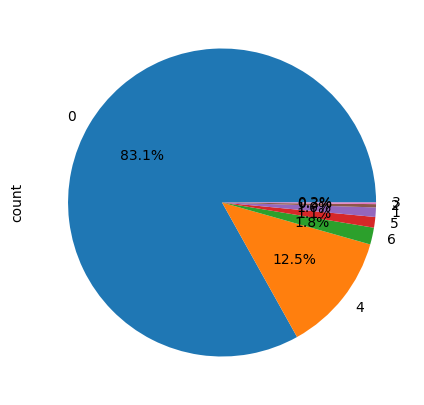

In [ ]:
#pie chart
df['label'].value_counts().plot(kind = "pie",autopct="%1.1f%%",figsize=(5,5))

In [ ]:
df['label'].unique()

array([2, 0, 4, 1, 6, 5, 3])

In [ ]:
# Map 0–6 to 'negative', 'neutral', 'positive'
def map_emotion(label):
    if label in [1, 2, 3, 5]:
        return 'negative'
    elif label in [4, 6]:
        return 'positive'
    else:
        return 'neutral'

df['category'] = df['label'].apply(map_emotion)


In [ ]:
df['category'].value_counts()

,count
category,
neutral,85572
positive,14708
negative,2699


**Resampling the data to balance it**

In [ ]:
from sklearn.utils import resample
import pandas as pd

df_positive = df[df['category'] == 'positive']
df_negative = df[df['category'] == 'negative']
df_neutral  = df[df['category'] == 'neutral']

target_size = min(len(df_positive), len(df_neutral), 10000)

# Upsample negative class to match positive
df_negative_upsampled = resample(
    df_negative,
    replace=True,
    n_samples=target_size,
    random_state=42
)
# Upsample negative class to match positive
df_positive_upsampled = resample(
    df_positive,
    replace=True,
    n_samples=target_size,
    random_state=42
)
# Downsample neutral class to match positive
df_neutral_downsampled = resample(
    df_neutral,
    replace=False,
    n_samples=target_size,
    random_state=42
)

# Combine all
df_balanced = pd.concat([df_positive_upsampled, df_negative_upsampled, df_neutral_downsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


In [ ]:
df_balanced['category'].value_counts()

,count
category,
positive,10000
neutral,10000
negative,10000


**Encoding the Labels**

In [ ]:
df = df_balanced
label_encoder = LabelEncoder()
df['category'] = label_encoder.fit_transform(df['category'])

In [ ]:

#save the label encoder's classes
with open('./label_encoder.json', 'w') as f:
    json.dump(list(label_encoder.classes_), f)

In [ ]:
df['category'].value_counts()

,count
category,
2,10000
1,10000
0,10000


In [ ]:
print(list(label_encoder.classes_))

['negative', 'neutral', 'positive']


<Axes: ylabel='count'>

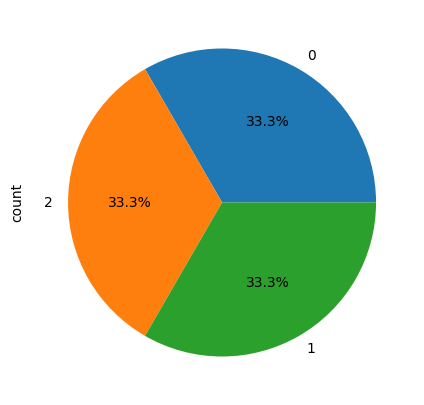

In [ ]:

#pie chart
df_balanced['category'].value_counts().plot(kind = "pie",autopct="%1.1f%%",figsize=(5,5))

In [ ]:
df.drop('label', axis=1, inplace=True)

# Textual Processing

In [ ]:
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
def lemmatization(text):
    lemmatizer= WordNetLemmatizer()

    text = text.split()

    text=[lemmatizer.lemmatize(y) for y in text]

    return " " .join(text)

def Removing_numbers(text):
    text=''.join([i for i in text if not i.isdigit()])
    return text

def lower_case(text):

    text = text.split()

    text=[y.lower() for y in text]

    return " " .join(text)

def Removing_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_small_sentences(df):
    for i in range(len(df)):
        if len(df.text.iloc[i].split()) < 3:
            df.text.iloc[i] = np.nan

def normalize_text(df):
    df.Text=df.Text.apply(lambda text : lower_case(text))
    df.Text=df.Text.apply(lambda text : Removing_numbers(text))
    df.Text=df.Text.apply(lambda text : Removing_urls(text))
    df.Text=df.Text.apply(lambda text : lemmatization(text))
    return df

def normalized_sentence(sentence):
    sentence= lower_case(sentence)
    sentence= Removing_numbers(sentence)
    sentence= Removing_urls(sentence)
    sentence= lemmatization(sentence)
    return sentence

In [ ]:
df['cleaned_text'] = df['text'].apply(normalized_sentence)


In [ ]:
df.text[0]

"Let me go to the back and get them . I'll be right back ."

In [ ]:
df.head()

,text,category,cleaned_text
0,Let me go to the back and get them . I'll be r...,2,let go back get . right back .
1,I had a bad start of the day . I was stuck in ...,0,bad start day . stuck bad traffic jam way miss...
2,You can't do that ! You can't charge me for a ...,0,can't ! can't charge mistake made !
3,That's great .,2,that's great .
4,Really ? Do I look happy all the time ?,2,really ? look happy time ?


# Splitting the Data

In [ ]:
#Train Test split
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_text'], df['category'], test_size=0.20, random_state=42,stratify=df['category'])

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24000,)
(6000,)
(24000,)
(6000,)


In [ ]:
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

In [ ]:
# Tokenization
tokenizer = Tokenizer(oov_token='UNK')
tokenizer.fit_on_texts(pd.concat([X_train, X_test], axis=0))

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
max_len = int(np.percentile([len(seq) for seq in X_train_seq], 95))

X_train = pad_sequences(X_train_seq, maxlen=max_len, padding='pre', truncating='pre')
X_test = pad_sequences(X_test_seq, maxlen=max_len, padding='pre', truncating='pre')


**Loading the pre-trained weights of Glove Encoding**

In [ ]:
vocab_size = len(tokenizer.index_word) + 1
embedding_index = {}
hits = 0
misses = 0

with open('/content/drive/MyDrive/Emotion Dataset/glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

embedding_dim = 100
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            hits += 1
        else:
            misses += 1

print("Converted %d words (%d misses)" % (hits, misses))

Converted 8294 words (377 misses)


In [ ]:
# Save the tokenizer
with open('./tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

In [ ]:
embedding_matrix.shape == (vocab_size, embedding_dim)


True

# Model Architecture

In [ ]:
print("\n--- Defining Model ---")
model = Sequential()
model.add(Embedding(vocab_size, 100, input_length=max_len,
                    weights=[embedding_matrix],
                    trainable=True))  # allow fine-tuning

model.add(Bidirectional(LSTM(256, return_sequences=True, dropout=0.4)))
model.add(Bidirectional(LSTM(256, dropout=0.4)))

model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax'))

input_shape = X_train.shape
model.build(input_shape)
model.summary()

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Computing Class Weights ---")
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Training Model
print("\n--- Training the Model ---")
start_time = time.time()
with tf.device('/GPU:0'):
    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_test, y_test_cat),
        epochs=50,
        batch_size=64,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=1
    )
print(f"\n✅ Training completed in {time.time() - start_time:.2f} seconds.")

print("\n--- Evaluating Model ---")
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

print("\n--- Classification Report ---")
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test, y_pred, target_names=['Neutral', 'Negative', 'Positive']))



--- Defining Model ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (24000, 30, 100)       │       867,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (24000, 30, 512)       │       731,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (24000, 512)           │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (24000, 64)            │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (24000, 64)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (24000, 3)             │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,206,275 (12.23 MB)

 Trainable params: 3,206,275 (12.23 MB)

 Non-trainable params: 0 (0.00 B)


--- Computing Class Weights ---
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}

--- Training the Model ---
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.4290 - loss: 1.9920 - val_accuracy: 0.5883 - val_loss: 1.3835
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.5954 - loss: 1.2853 - val_accuracy: 0.6283 - val_loss: 1.0475
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6302 - loss: 1.0124 - val_accuracy: 0.6480 - val_loss: 0.9078
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.6446 - loss: 0.8985 - val_accuracy: 0.6595 - val_loss: 0.8384
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6598 - loss: 0.8342 - val_accuracy: 0.6657 - val_loss: 0.8062
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6746 - loss: 0.7895 - val_accuracy: 0.6757 - val_loss: 0.7753
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.6831 - loss: 0.7616

**Saving the model**

In [ ]:
model.save("./lstm_model Emotion Detection.keras")

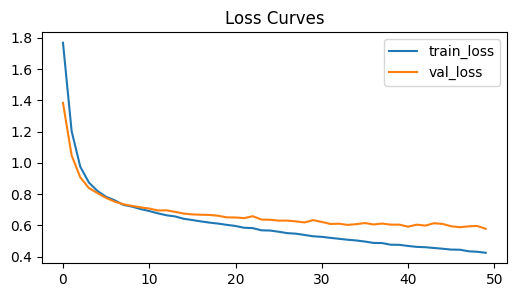

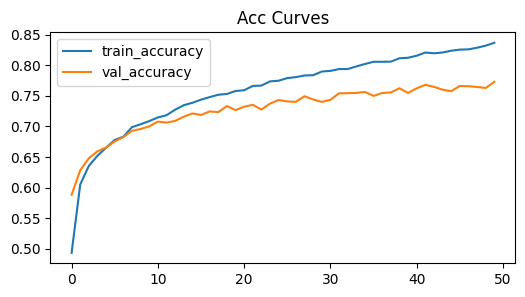

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 3))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curves")
plt.show()
plt.figure(figsize=(6, 3))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.title("Acc Curves")
plt.show()


**Confusion Matrix**

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


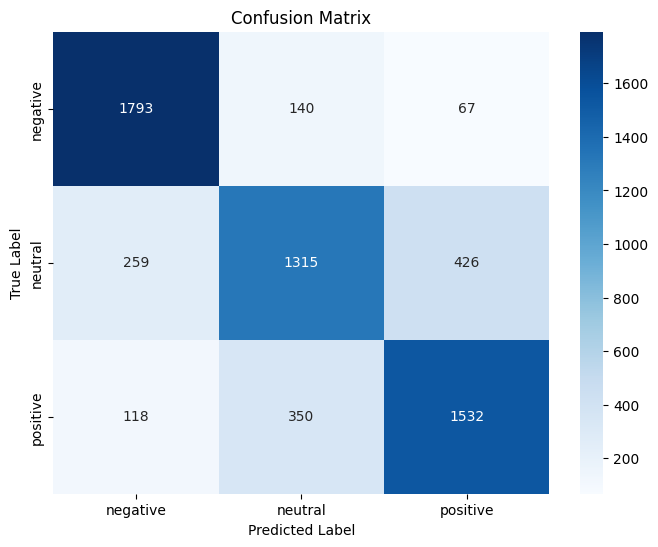

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get the true categories for the test set
y_test_classes = np.argmax(y_test_cat, axis=1)

# Generate the confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Get the class labels from the LabelEncoder
class_labels = label_encoder.classes_

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

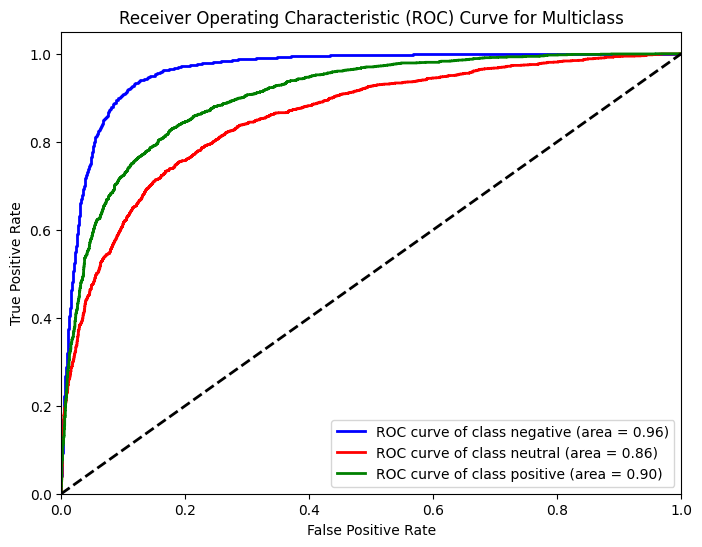

In [ ]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multiclass')
plt.legend(loc="lower right")
plt.show()

In [ ]:
!pip freeze > requirements.txt

In [ ]:
with open("label_encoder.json") as f:
    label_map = json.load(f)


# Insights

- The original dataset was **heavily imbalanced**, especially for the negative class.
- Mapping 7 labels into 3 broader classes helped simplify the task.
- Even after resampling, the **model struggled to generalize well on real negative samples**.
- Preprocessing plays a critical role, but oversampling rare emotion types may not be enough alone.
